# Gradient-Based Poisoning em VQR

Este notebook implementa um ataque de poisoning para regressao quantica (VQR).
A ideia do laco externo e mover amostras envenenadas para maximizar o erro de validacao do modelo treinado com esses pontos.

## 1) Imports e configuracao

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.algorithms.regressors import VQR

np.random.seed(7)

## 2) Geracao e divisao do dataset

In [2]:
n_samples = 170
x_min, x_max = -np.pi, np.pi
noise = 0.06

X = np.random.uniform(x_min, x_max, size=(n_samples, 1))
y = np.sin(X[:, 0]) + noise * np.random.randn(n_samples)

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=7,
 )

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_raw,
    y_train_raw,
    test_size=0.3,
    random_state=7,
 )

print('Shapes:', X_fit.shape, X_val.shape, X_test.shape)

Shapes: (88, 1) (39, 1) (43, 1)


## 3) Treino do modelo limpo (baseline)

In [3]:
def build_vqr(maxiter=60):
    x_param = Parameter('x')
    theta = Parameter('theta')

    feature_map = QuantumCircuit(1, name='feature_map')
    feature_map.ry(x_param, 0)

    ansatz = QuantumCircuit(1, name='ansatz')
    ansatz.ry(theta, 0)

    estimator = StatevectorEstimator()
    optimizer = COBYLA(maxiter=maxiter)

    return VQR(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        estimator=estimator,
    )


def train_vqr(X_train_local, y_train_local, maxiter=60):
    model = build_vqr(maxiter=maxiter)
    model.fit(X_train_local, y_train_local)
    return model


def mse_on_dataset(model, X_eval, y_eval):
    pred = np.asarray(model.predict(X_eval))
    return float(mean_squared_error(y_eval, pred))


clean_model = train_vqr(X_fit, y_fit, maxiter=60)
clean_val_mse = mse_on_dataset(clean_model, X_val, y_val)
clean_test_mse = mse_on_dataset(clean_model, X_test, y_test)

print(f'Clean validation MSE: {clean_val_mse:.4f}')
print(f'Clean test MSE:       {clean_test_mse:.4f}')

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Clean validation MSE: 0.0035
Clean test MSE:       0.0037


## 4) Ataque gradient-based poisoning

In [4]:
poison_count = 3
outer_steps = 4
finite_diff_eps = 0.08
poison_lr = 0.25
target_value = 0.9

rng = np.random.default_rng(7)
poison_indices = rng.choice(len(X_fit), size=poison_count, replace=False)

X_base = np.delete(X_fit, poison_indices, axis=0)
y_base = np.delete(y_fit, poison_indices, axis=0)
X_poison = X_fit[poison_indices].copy()
y_poison = np.full(poison_count, target_value, dtype=float)

print('Poison indices:', poison_indices)
print('Initial poison points:')
print(X_poison)


def poisoned_dataset(X_poison_candidate):
    X_train_poisoned = np.vstack([X_base, X_poison_candidate])
    y_train_poisoned = np.concatenate([y_base, y_poison])
    return X_train_poisoned, y_train_poisoned


def attack_objective(X_poison_candidate):
    X_train_poisoned, y_train_poisoned = poisoned_dataset(X_poison_candidate)
    model = train_vqr(X_train_poisoned, y_train_poisoned, maxiter=35)
    return mse_on_dataset(model, X_val, y_val), model


def finite_difference_gradient(X_poison_candidate):
    gradient = np.zeros_like(X_poison_candidate)
    base_mse, _ = attack_objective(X_poison_candidate)
    for row in range(X_poison_candidate.shape[0]):
        plus = X_poison_candidate.copy()
        minus = X_poison_candidate.copy()
        plus[row, 0] = np.clip(plus[row, 0] + finite_diff_eps, x_min, x_max)
        minus[row, 0] = np.clip(minus[row, 0] - finite_diff_eps, x_min, x_max)
        mse_plus, _ = attack_objective(plus)
        mse_minus, _ = attack_objective(minus)
        gradient[row, 0] = (mse_plus - mse_minus) / (2.0 * finite_diff_eps)
    return base_mse, gradient


history = []
for step in range(outer_steps):
    mse_value, gradient = finite_difference_gradient(X_poison)
    X_poison = np.clip(X_poison + poison_lr * gradient, x_min, x_max)
    poisoned_val_mse_step, _ = attack_objective(X_poison)
    history.append((step + 1, poisoned_val_mse_step, np.linalg.norm(gradient)))
    print(
        f'Step {step + 1}: validation MSE = {poisoned_val_mse_step:.4f}, '
        f'gradient norm = {np.linalg.norm(gradient):.4f}'
    )

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Poison indices: [81 54 60]
Initial poison points:
[[0.84433362]
 [0.1529679 ]
 [2.14556148]]


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. I

Step 1: validation MSE = 0.0039, gradient norm = 0.0049


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. I

Step 2: validation MSE = 0.0048, gradient norm = 0.0060


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. I

Step 3: validation MSE = 0.0044, gradient norm = 0.0064


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Step 4: validation MSE = 0.0043, gradient norm = 0.0067


## 5) Avaliacao do modelo contaminado

In [5]:
final_poisoned_X, final_poisoned_y = poisoned_dataset(X_poison)
poisoned_model = train_vqr(final_poisoned_X, final_poisoned_y, maxiter=60)

poisoned_val_mse = mse_on_dataset(poisoned_model, X_val, y_val)
poisoned_test_mse = mse_on_dataset(poisoned_model, X_test, y_test)

pred_clean_test = np.asarray(clean_model.predict(X_test))
pred_poisoned_test = np.asarray(poisoned_model.predict(X_test))

tol = 0.12
asr_clean = np.mean(np.abs(pred_clean_test - target_value) <= tol)
asr_poisoned = np.mean(np.abs(pred_poisoned_test - target_value) <= tol)

print(f'Poisoned validation MSE: {poisoned_val_mse:.4f}')
print(f'Poisoned test MSE:       {poisoned_test_mse:.4f}')
print(f'Test MSE increase:       {poisoned_test_mse - clean_test_mse:.4f}')
print(f'ASR proxy clean:         {asr_clean:.4f}')
print(f'ASR proxy poisoned:      {asr_poisoned:.4f}')

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Poisoned validation MSE: 0.0047
Poisoned test MSE:       0.0041
Test MSE increase:       0.0004
ASR proxy clean:         0.2791
ASR proxy poisoned:      0.2558


## 6) Visualizacoes e interpretacao

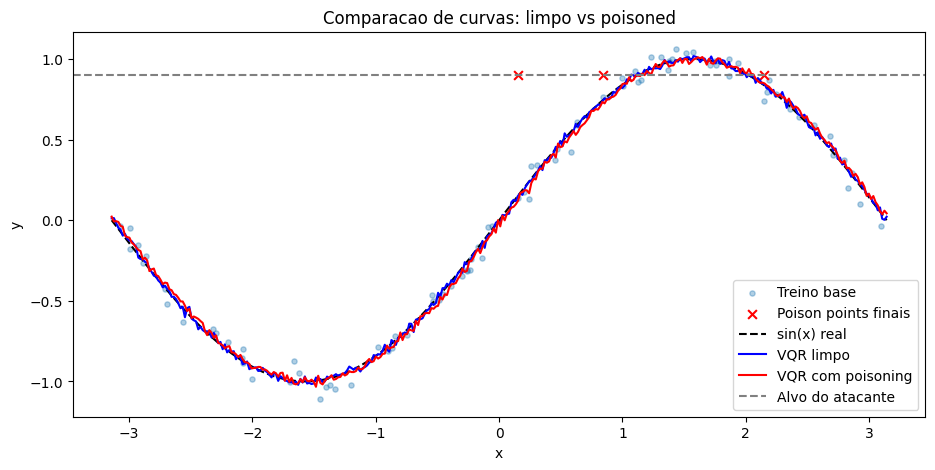

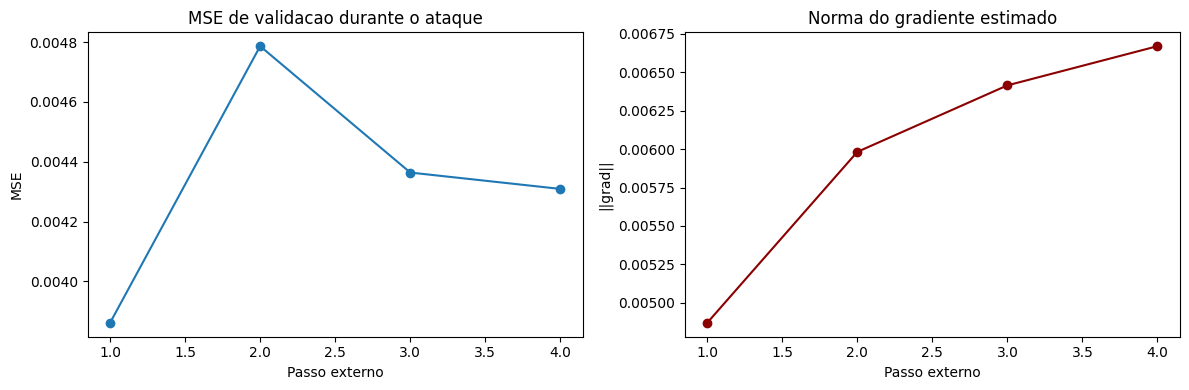

In [6]:
X_plot = np.linspace(x_min, x_max, 350).reshape(-1, 1)
y_plot_clean = np.asarray(clean_model.predict(X_plot))
y_plot_poisoned = np.asarray(poisoned_model.predict(X_plot))

plt.figure(figsize=(11, 5))
plt.scatter(X_fit[:, 0], y_fit, s=14, alpha=0.35, label='Treino base')
plt.scatter(X_poison[:, 0], y_poison, s=40, marker='x', color='red', label='Poison points finais')
plt.plot(X_plot[:, 0], np.sin(X_plot[:, 0]), 'k--', label='sin(x) real')
plt.plot(X_plot[:, 0], y_plot_clean, 'b', label='VQR limpo')
plt.plot(X_plot[:, 0], y_plot_poisoned, 'r', label='VQR com poisoning')
plt.axhline(target_value, color='gray', linestyle='--', label='Alvo do atacante')
plt.title('Comparacao de curvas: limpo vs poisoned')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

if history:
    steps, mses, norms = zip(*history)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(steps, mses, marker='o')
    ax[0].set_title('MSE de validacao durante o ataque')
    ax[0].set_xlabel('Passo externo')
    ax[0].set_ylabel('MSE')

    ax[1].plot(steps, norms, marker='o', color='darkred')
    ax[1].set_title('Norma do gradiente estimado')
    ax[1].set_xlabel('Passo externo')
    ax[1].set_ylabel('||grad||')
    plt.tight_layout()
    plt.show()